# Laboratorio 5 — Transformer Encoder · Clasificación de Géneros Musicales
> Audio → **Mel Spectrogram** (imagen 2D) → parches con `unfold` → Transformer  


## 1 · Instalación

In [ ]:
!pip install pytorch-lightning torchaudio librosa -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.9 MB/s eta 0:00:00


## 2 · Importaciones

In [ ]:
import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import pytorch_lightning as pl
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from torch.utils.data import DataLoader, random_split

print("PyTorch    :", torch.__version__)
print("Torchaudio :", torchaudio.__version__)
print("Lightning  :", pl.__version__)
print("GPU        :", torch.cuda.is_available())

PyTorch    : 2.10.0+cu128
Torchaudio : 2.10.0+cu128
Lightning  : 2.6.1
GPU        : True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3 · Dataset GTZAN
El dataset tiene 10 géneros × 100 clips de 30 s = **1 000 audios**.  
Se carga desde Google Drive (sin re-descargar cada sesión).

In [ ]:
import os
import torchaudio
from torch.utils.data import Dataset

GTZAN_ROOT = '/content/drive/MyDrive/gtzan/genres_original'

class GTZANRaw(Dataset):
    def __init__(self, root):
        self.samples = []
        for genre in sorted(os.listdir(root)):
            genre_path = os.path.join(root, genre)
            if not os.path.isdir(genre_path):
                continue
            for fname in sorted(os.listdir(genre_path)):
                if fname.endswith('.wav'):
                    self.samples.append((os.path.join(genre_path, fname), genre))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, ix):
        path, label = self.samples[ix]
        waveform, sample_rate = torchaudio.load(path)
        return waveform, sample_rate, label

raw_dataset = GTZANRaw(GTZAN_ROOT)
print("Total de clips:", len(raw_dataset))

# Verificar
waveform, sample_rate, label = raw_dataset[0]
print("Waveform:", waveform.shape, "| SR:", sample_rate, "| Género:", label)

Total de clips: 1000
Waveform: torch.Size([1, 661794]) | SR: 22050 | Género: blues


## 4 · Exploración rápida

Waveform : torch.Size([1, 661794]) | SR: 22050 | Género: blues


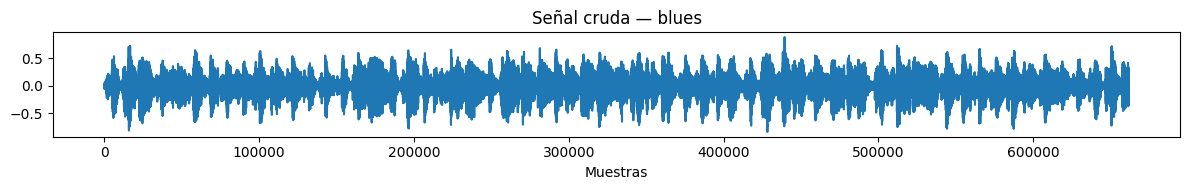

In [ ]:
waveform, sample_rate, label = raw_dataset[0]
print("Waveform :", waveform.shape, "| SR:", sample_rate, "| Género:", label)

plt.figure(figsize=(12, 2))
plt.plot(waveform[0].numpy())
plt.title(f"Señal cruda — {label}"); plt.xlabel("Muestras"); plt.tight_layout(); plt.show()

## 5 · Audio → Mel Spectrogram
Convertimos la señal 1D en una imagen 2D **(frecuencia × tiempo)**.

Espectrograma: torch.Size([1, 64, 130])


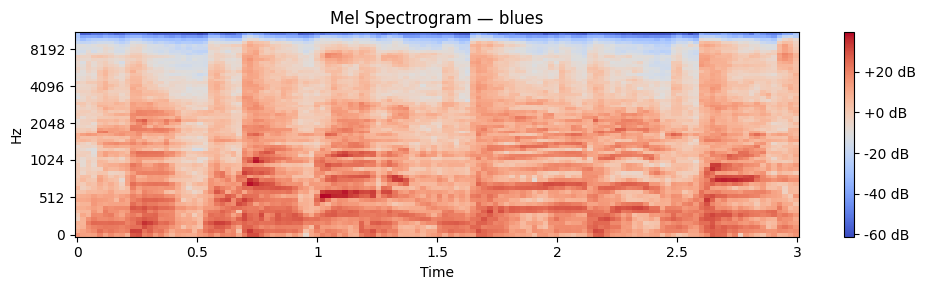

In [ ]:
SAMPLE_RATE = 22050
N_MELS      = 64
N_FFT       = 1024
HOP_LENGTH  = 512
N_SAMPLES   = SAMPLE_RATE * 3          # 3 segundos
FIXED_TIME  = 128                      # columnas fijas del espectrograma

mel_tf = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT,
                           hop_length=HOP_LENGTH, n_mels=N_MELS)
to_db  = T.AmplitudeToDB()

spec = to_db(mel_tf(waveform[:, :N_SAMPLES]))
print("Espectrograma:", spec.shape)    # (1, 64, T)

plt.figure(figsize=(10, 3))
librosa.display.specshow(spec.squeeze(0).numpy(), sr=SAMPLE_RATE,
                         hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram — {label}"); plt.tight_layout(); plt.show()

## 6 · Mel Spectrogram por género

In [ ]:
import os
import torchaudio
from torch.utils.data import Dataset

GTZAN_ROOT = '/content/drive/MyDrive/gtzan/genres_original'

# Archivos corruptos conocidos del dataset GTZAN
CORRUPTED = {'jazz.00054.wav'}

class GTZANRaw(Dataset):
    def __init__(self, root):
        self.samples = []
        for genre in sorted(os.listdir(root)):
            genre_path = os.path.join(root, genre)
            if not os.path.isdir(genre_path):
                continue
            for fname in sorted(os.listdir(genre_path)):
                if fname.endswith('.wav') and fname not in CORRUPTED:
                    self.samples.append((os.path.join(genre_path, fname), genre))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, ix):
        path, label = self.samples[ix]
        waveform, sample_rate = torchaudio.load(path)
        return waveform, sample_rate, label

raw_dataset = GTZANRaw(GTZAN_ROOT)
print("Total de clips:", len(raw_dataset))  # debe dar 999

waveform, sample_rate, label = raw_dataset[0]
print("Waveform:", waveform.shape, "| SR:", sample_rate, "| Género:", label)

Total de clips: 999
Waveform: torch.Size([1, 661794]) | SR: 22050 | Género: blues


## 7 · Preprocesado: audio → tensor `(1, 64, 128)`
Normalización por instancia para que todos los clips tengan media 0 y std 1.

In [ ]:
# Paso 7 corregido — corte ALEATORIO durante entrenamiento
def audio_to_spectrogram(waveform, train=True):
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    total = waveform.shape[1]

    if total >= N_SAMPLES:
        if train:
            # Corte aleatorio → cada época ve una parte distinta del clip
            max_start = total - N_SAMPLES
            start = torch.randint(0, max_start, (1,)).item()
        else:
            # En validación siempre el mismo corte (reproducible)
            start = (total - N_SAMPLES) // 2
        waveform = waveform[:, start : start + N_SAMPLES]
    else:
        waveform = F.pad(waveform, (0, N_SAMPLES - total))

    spec = to_db(mel_tf(waveform))
    t = spec.shape[2]
    spec = spec[:, :, :FIXED_TIME] if t >= FIXED_TIME else F.pad(spec, (0, FIXED_TIME - t))
    return (spec - spec.mean()) / (spec.std() + 1e-8)

## 8 · Espectrograma → parches con `unfold`
Igual que las imágenes MNIST en el cuadernillo 04.

| | Cuadernillo 04 | Lab 5 |
|---|---|---|
| Imagen | 28×28 px | 64×128 mel |
| Parche | 7×7 = **49** vals | 16×16 = **256** vals |
| N° parches | 4×4 = **16** | 4×8 = **32** |

Espectrograma: torch.Size([64, 128]) → Parches: torch.Size([32, 256])


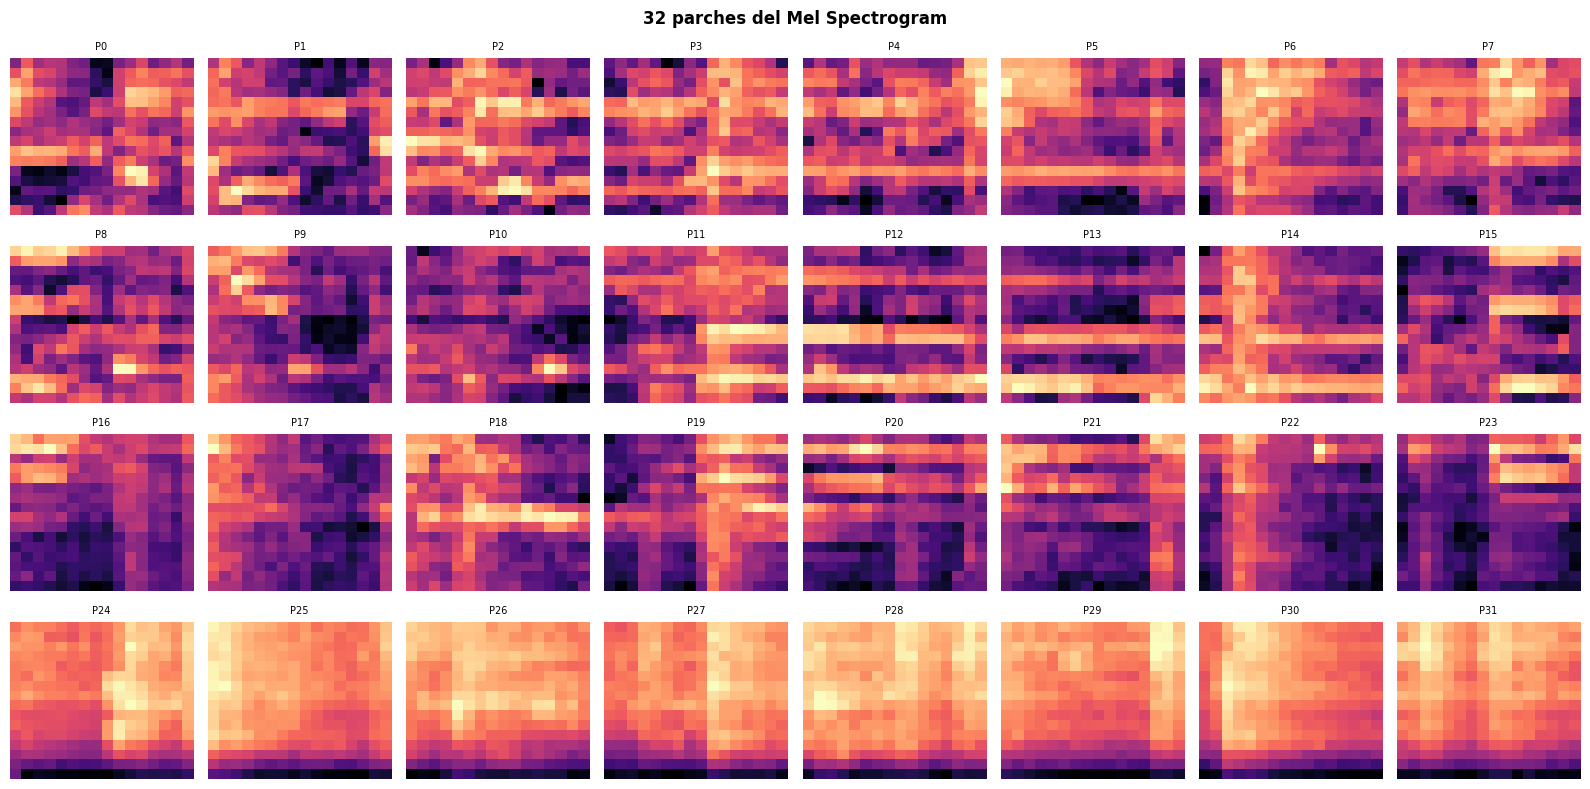

In [ ]:
PATCH_H, PATCH_W = 16, 16

spec_2d = audio_to_spectrogram(waveform).squeeze(0)          # (64, 128)
patches = spec_2d.unfold(0, PATCH_H, PATCH_H)                # (4, 128, 16)
patches = patches.unfold(1, PATCH_W, PATCH_W)                # (4,   8, 16, 16)
patches = patches.contiguous().view(-1, PATCH_H * PATCH_W)   # (32, 256)
print("Espectrograma:", spec_2d.shape, "→ Parches:", patches.shape)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(patches[i].view(PATCH_H, PATCH_W).numpy(), cmap='magma', aspect='auto')
    ax.axis('off'); ax.set_title(f'P{i}', fontsize=7)
plt.suptitle('32 parches del Mel Spectrogram', fontweight='bold'); plt.tight_layout(); plt.show()

## 9 · GTZANDataset — mismo patrón que `AttnDataset` del cuadernillo 04

In [ ]:
# Paso 9 corregido — Dataset que sabe si está en train o val
class GTZANDataset(torch.utils.data.Dataset):
    def __init__(self, raw, ph=16, pw=16, train=True):
        self.data  = raw
        self.ph    = ph
        self.pw    = pw
        self.train = train   # ← controla el corte aleatorio

    def __len__(self):
        return len(self.data)

    def __getitem__(self, ix):
        wf, _, label = self.data[ix]
        spec = audio_to_spectrogram(wf, train=self.train).squeeze(0)
        p = spec.unfold(0, self.ph, self.ph).unfold(1, self.pw, self.pw)
        p = p.contiguous().view(-1, self.ph * self.pw)
        return p, torch.tensor(GENRE2IDX[label]).long()

## 10 · GTZANDataModule

In [ ]:
# Paso 10 corregido — DataModule que pasa train=True/False
class GTZANDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=16, val_split=0.2, seed=42):
        super().__init__()
        self.batch_size = batch_size
        self.val_split  = val_split
        self.seed       = seed

    def setup(self, stage=None):
        raw   = GTZANRaw(GTZAN_ROOT)
        n_val = int(len(raw) * self.val_split)
        gen   = torch.Generator().manual_seed(self.seed)
        indices = torch.randperm(len(raw), generator=gen).tolist()

        train_idx = indices[n_val:]
        val_idx   = indices[:n_val]

        # Dataset separado para train y val con flag distinto
        full = GTZANRaw(GTZAN_ROOT)
        self.train_ds = GTZANDataset(
            [full[i] for i in train_idx], train=True)
        self.val_ds   = GTZANDataset(
            [full[i] for i in val_idx],   train=False)

        print(f"Train: {len(self.train_ds)} | Val: {len(self.val_ds)}")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True, num_workers=2)
    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          num_workers=2)

## 11 · Arquitectura Transformer
Tres bloques reutilizados directamente del cuadernillo 04.

In [ ]:
# Paso 11 — volver al modelo pequeño que funcionó mejor
class AudioTransformer(nn.Module):
    def __init__(self, n_input=256, n_embd=32, seq_len=32,
                 n_heads=4, n_layers=1, n_classes=10, dropout=0.3):
        super().__init__()
        self.inp_emb     = nn.Linear(n_input, n_embd)
        self.inp_drop    = nn.Dropout(dropout)
        self.pos_emb     = nn.Parameter(torch.zeros(1, seq_len, n_embd))
        self.transformer = nn.Sequential(
            *[TransformerBlock(n_embd, n_heads, dropout) for _ in range(n_layers)]
        )
        self.ln = nn.LayerNorm(n_embd)
        self.fc = nn.Linear(n_embd, n_classes)

    def forward(self, x):
        e = self.inp_drop(self.inp_emb(x) + self.pos_emb)
        z = self.transformer(e)
        z = self.ln(z.mean(dim=1))
        return self.fc(z)

t = AudioTransformer()
print("Salida:", t(torch.randn(4, 32, 256)).shape)
print("Parámetros:", f"{sum(p.numel() for p in t.parameters()):,}")

Salida: torch.Size([4, 10])
Parámetros: 34,922


## 12 · LightningModule

In [ ]:
# Paso 12 · LightningModule

from pytorch_lightning.callbacks import EarlyStopping

class Model(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.lr    = lr
        self.model = AudioTransformer()

    def forward(self, x):
        return self.model(x)

    def predict(self, x):
        with torch.no_grad():
            return torch.argmax(self(x), dim=1)

    def _step(self, batch):
        x, y  = batch
        y_hat = self(x)
        loss  = F.cross_entropy(y_hat, y, label_smoothing=0.1)
        acc   = (y_hat.argmax(1) == y).float().mean()
        return loss, acc

    def training_step(self, batch, _):
        loss, acc = self._step(batch)
        self.log('loss', loss, prog_bar=True)
        self.log('acc',  acc,  prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        loss, acc = self._step(batch)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=4)
        return {'optimizer': opt,
                'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}}

# Verificación
m = Model()
print("Model OK — parámetros:", f"{sum(p.numel() for p in m.parameters()):,}")

## 13 · Entrenamiento
> 💡 Activa GPU: *Entorno de ejecución → T4 GPU*

In [ ]:
model = Model(lr=1e-3)
dm    = GTZANDataModule(batch_size=16)

early_stop = EarlyStopping(monitor='val_loss', patience=12, mode='min', verbose=True)

trainer = pl.Trainer(
    max_epochs=80,
    accelerator='auto', devices=1,
    logger=None,
    enable_checkpointing=False,
    callbacks=[early_stop],
)
trainer.fit(model, dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Train: 800 | Val: 199


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ AudioTransformer │ 34.9 K │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 34.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 34.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 1.955
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.221 >= min_delta = 0.0. New best score: 1.734
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.072 >= min_delta = 0.0. New best score: 1.662
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 1.631
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.045 >= min_delta = 0.0. New best score: 1.586
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.030 >= min_delta = 0.0. New best score: 1.555
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.007 >= min_delta = 0.0. New best score: 1.548
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.012 >= min_delta = 0.0. New best score: 1.536
INFO:pytorch_lightning.callbacks.ear

## 14 · Evaluación

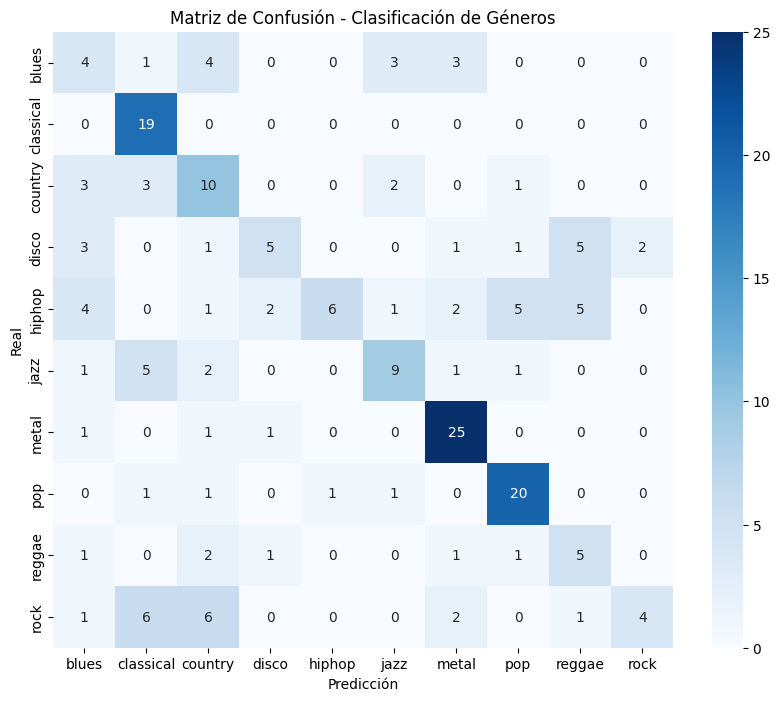

              precision    recall  f1-score   support

       blues       0.22      0.27      0.24        15
   classical       0.54      1.00      0.70        19
     country       0.36      0.53      0.43        19
       disco       0.56      0.28      0.37        18
      hiphop       0.86      0.23      0.36        26
        jazz       0.56      0.47      0.51        19
       metal       0.71      0.89      0.79        28
         pop       0.69      0.83      0.75        24
      reggae       0.31      0.45      0.37        11
        rock       0.67      0.20      0.31        20

    accuracy                           0.54       199
   macro avg       0.55      0.52      0.48       199
weighted avg       0.59      0.54      0.51       199



In [ ]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones
model.eval()
all_preds, all_labels = [], []
for xb, yb in dm.val_dataloader():
    preds = model.predict(xb)
    all_preds.extend(preds.numpy())
    all_labels.extend(yb.numpy())

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title('Matriz de Confusión - Clasificación de Géneros')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Reporte detallado
print(classification_report(all_labels, all_preds, target_names=GENRES))